# 7. Dendrogram annot

Part of the **[Fig. 1 chapter](fig1.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}npc.tsv'`  ·  _metadata_
- `f'{indir}5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'{indir}celltype_annot.tsv'`  ·  _table_
- `f'{indir}L2final_celltype_L2both_new.tsv'`  ·  _table_
- `f'{indir}../../L1color.tsv'`  ·  _metadata: color_
- `f'{indir}L1/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L2_hiconly/{l1_name}/100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L2/{l1_name}/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'dendro_annot/All_{method_dist}_{method_hclust}.dendro'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
from glob import glob
import joblib
import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns

from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from ALLCools.mcds import MCDS

from sklearn.metrics import pairwise_distances, roc_auc_score, average_precision_score
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from concurrent.futures import ProcessPoolExecutor, as_completed

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/clustering/merged/'
outdir = f'{ENTEX_ROOT}/analysis/'
# L1_list = np.sort([xx.split('/')[-2] for xx in glob(f'{indir}L2/*/5kCG100k3C_embed.h5ad')])
# print(len(L1_list))


In [4]:
npc = pd.read_csv(f'{indir}npc.tsv', sep='\t', header=None, index_col=0, names=['npc_cg', 'npc_3c'])

In [5]:
meta = anndata.read_h5ad(f'{indir}5kCG100k3C_summary.h5ad').obs

## map abbr to annot
celltype_df = pd.read_csv(f'{indir}celltype_annot.tsv', sep='\t', header=0, index_col=0).fillna('')
celltype_df['celltype_annot'] = (celltype_df['L1_annot'] + ' ' + celltype_df['celltype_annot'].astype(str)).str.rstrip()
ct_annot = celltype_df[['celltype_abbr', 'celltype_annot']].drop_duplicates().set_index('celltype_abbr')['celltype_annot']
ct_annot = ct_annot[~ct_annot.index.duplicated()]

## map L2final to abbr
cluster_meta = pd.read_csv(f'{indir}L2final_celltype_L2both_new.tsv', sep='\t', index_col=None, header=0, dtype={'label': str}).fillna('')
cluster_meta['celltype_L2_both_annot'] = (cluster_meta['celltype_abbr'].map(ct_annot) + ' ' + cluster_meta['label']).str.rstrip()
clustermap = cluster_meta[['celltype_L2_both_annot', 'L2_final']].drop_duplicates().set_index('L2_final')['celltype_L2_both_annot']

meta['celltype_L2_both_annot'] = meta['L2_final'].astype(str).map(clustermap)


In [6]:
L1_meta = pd.read_csv(f'{indir}../../L1color.tsv', sep='\t', header=0, index_col=0)
L1_annot = celltype_df[['L1', 'L1_annot']].drop_duplicates().set_index('L1')['L1_annot']


In [7]:
celltype_df

,L1,L1_annot,L1_abbr,L2_any,celltype_annot,celltype_abbr
c33-c0,c33,Endo Lymphatic,Endo Lym,c0,Endo Lymphatic Esophagus,Endo Lym Esp
c33-c1,c33,Endo Lymphatic,Endo Lym,c1,Endo Lymphatic Skin,Endo Lym Skn
c33-c2,c33,Endo Lymphatic,Endo Lym,c2,Endo Lymphatic Breast,Endo Lym Brs
c33-c3,c33,Endo Lymphatic,Endo Lym,c3,Endo Lymphatic Mix,Endo Lym Mix
c33-c4,c33,Endo Lymphatic,Endo Lym,c4,Endo Lymphatic Mix,Endo Lym Mix
...,...,...,...,...,...,...
c4-3c14,c4,Epi Gastric,Epi Gas,3c14,Epi Gastric Endocrine,Endocrine
c4-3c15,c4,Epi Gastric,Epi Gas,3c15,Epi Gastric Neck,Neck
c4-3c16,c4,Epi Gastric,Epi Gas,3c16,Epi Gastric Chief,Chief
c4-3c17,c4,Epi Gastric,Epi Gas,3c17,Epi Gastric Chief,Chief


In [8]:
adata = anndata.read_h5ad(f'{indir}L1/5kCG100k3C_embed.h5ad')
adata.obs['L1_annot'] = adata.obs['L1'].astype(str)
L1map = 'c' + adata.obs['L1'].value_counts().reset_index().reset_index().set_index('L1')['index'].astype(str)
adata.obs['L1'] = adata.obs['L1_annot'].map(L1map)
adata


AnnData object with n_obs × n_vars = 86689 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'L1', 'L1_annot'
    obsm: '5kCG100k3C_u50pc50', '5kCG100k3C_u50pc50_tsne', 'X_tsne'

In [9]:
# ct = 'Epi-Endcri'
# adata = anndata.read_h5ad(f'{indir}L2/{ct}/5kCG100k3C_embed.h5ad')
# # labelany = np.load(f'{outdir}{ct}_mergeany_rocpr.npy', allow_pickle=True)
# adata.obs['celltype'] = meta['celltype_L2_both_annot'].copy()
# adata

In [10]:
cpu = 20
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'
# method_dist = 'euclidean'
# method_hclust = 'ward'


In [11]:
# using the cluster centroids in PC space to calculate dendrogram
npc_cg, npc_3c = 50, 50 # npc.loc[ct].values    

pc_center = get_pc_centers(adata, obsm=f'5kCG100k3C_u{npc_cg}pc{npc_3c}', group='L1')

# calculate the cluster dendrogram using R package pvclust
dendro = Dendrogram(nboot=nboot,
                    method_dist=method_dist,
                    method_hclust=method_hclust,
                    n_jobs=32)
dendro.fit(pc_center)


Creating a temporary cluster...

done:


socket cluster with 32 nodes on host ‘localhost’

Multiscale bootstrap... 

Done.


In [12]:
def label_branch(pos, neg):
    
    global label, count, data_cg, data_3c
    selc = label.isin(list(pos) + list(neg))
    if count.loc[pos].sum()>count.loc[neg].sum():
        label_dict = {xx:1 for xx in pos} | {xx:0 for xx in neg}
    else:
        label_dict = {xx:1 for xx in neg} | {xx:0 for xx in pos}
    # print(label_dict, selc.sum())
    # selc = np.random.permutation(np.where(selc)[0])
    result = np.zeros((2,2))
    for i,data in enumerate([data_cg, data_3c]):
        X = data[selc]
        y = label.values[selc].map(label_dict)
        pred = np.zeros(len(y))
        for train_index, test_index in skf.split(X, y):
            X_train, X_test, y_train, y_test = X[train_index], X[test_index], y[train_index], y[test_index]
            pred[test_index] = clf.fit(X_train, y_train).predict_proba(X_test)[:,1]
        result[i,0] = roc_auc_score(y, pred)
        result[i,1] = average_precision_score(y, pred)
    return result
    

In [13]:
adata.obs['celltype'] = meta['L1'].copy()
data_cg = normalize(adata.obsm[f'5kCG100k3C_u{npc_cg}pc{npc_3c}'][:, :npc_cg], axis=1)
data_3c = normalize(adata.obsm[f'5kCG100k3C_u{npc_cg}pc{npc_3c}'][:, -npc_3c:], axis=1)
clf = LogisticRegression(class_weight='balanced')
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
label = adata.obs['celltype'].astype('category')
count = label.astype(str).value_counts()

node_dict = {i: [xx] for i,xx in enumerate(pc_center.index[::-1])}
alignment = []
for xx in dendro.linkage.iloc[:, :2].values:
    alignment.append([node_dict[xx[0]], node_dict[xx[1]]])
    node_dict[len(node_dict)] = node_dict[xx[0]] + node_dict[xx[1]]

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct_pair, node in zip(alignment, dendro.linkage.index):
        future = executor.submit(
            label_branch,
            pos=ct_pair[0],
            neg=ct_pair[1],
        )
        futures[future] = node

    result = {}
    for future in as_completed(futures):
        node = futures[future]
        tmp = future.result()
        result[node] = tmp.flatten()

result = pd.DataFrame(result, index=['CG_roc', 'CG_pr', '3C_roc', '3C_pr']).T
dendro.linkage = pd.concat([dendro.linkage, result], axis=1)


In [14]:
joblib.dump(dendro, f'dendro_annot/All_{method_dist}_{method_hclust}.dendro')


In [15]:
pd.Series(dendro.dendrogram['ivl'], index=dendro.dendrogram['leaves']).sort_index()

0      c9
1      c8
2      c7
3      c6
4      c5
5      c4
6     c34
7     c33
8     c32
9     c31
10    c30
11     c3
12    c29
13    c28
14    c27
15    c26
16    c25
17    c24
18    c23
19    c22
20    c21
21    c20
22     c2
23    c19
24    c18
25    c17
26    c16
27    c15
28    c14
29    c13
30    c12
31    c11
32    c10
33     c1
34     c0
dtype: object

In [16]:
l1order = dendro.dendrogram['ivl'].copy()

for l1 in l1order:
    l1_name = L1_meta.loc[l1, 'L1_abbr'].replace(' ','-').replace('/','_')
    print(l1_name)
    npc_cg, npc_3c = npc.loc[l1_name].values    
    if l1 in ['c4','c8']:
        adata = anndata.read_h5ad(f'{indir}L2_hiconly/{l1_name}/100k3C_embed.h5ad')
        obsm = f'100k3C_pc{npc_3c}_seuratL2'
    else:
        adata = anndata.read_h5ad(f'{indir}L2/{l1_name}/5kCG100k3C_embed.h5ad')
        obsm = f'5kCG100k3C_u{npc_cg}pc{npc_3c}'
    adata.obs['celltype'] = meta['celltype_L2_both_annot'].copy()
    nc = len(adata.obs['celltype'].unique())
    if nc==1:
        continue
        
#     pc_center = get_pc_centers(adata, obsm=obsm, group='celltype')
#     dendro = Dendrogram(nboot=nboot,
#                         method_dist=method_dist,
#                         method_hclust=method_hclust,
#                         n_jobs=32)
#     dendro.fit(pc_center)

#     adata = anndata.read_h5ad(f'{indir}L2/{l1_name}/5kCG100k3C_embed.h5ad')
#     adata.obs['celltype'] = meta['celltype_L2_both_annot'].copy()
#     data_cg = normalize(adata.obsm[f'5kCG100k3C_u{npc_cg}pc{npc_3c}'][:, :npc_cg], axis=1)
#     data_3c = normalize(adata.obsm[f'5kCG100k3C_u{npc_cg}pc{npc_3c}'][:, -npc_3c:], axis=1)
#     clf = LogisticRegression(class_weight='balanced')
#     skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
#     label = adata.obs['celltype'].astype('category')
#     count = label.astype(str).value_counts()

#     node_dict = {i: [xx] for i,xx in enumerate(pc_center.index[::-1])}
#     alignment = []
#     for xx in dendro.linkage.iloc[:, :2].values:
#         alignment.append([node_dict[xx[0]], node_dict[xx[1]]])
#         node_dict[len(node_dict)] = node_dict[xx[0]] + node_dict[xx[1]]

#     with ProcessPoolExecutor(cpu) as executor:
#         futures = {}
#         for ct_pair, node in zip(alignment, dendro.linkage.index):
#             future = executor.submit(
#                 label_branch,
#                 pos=ct_pair[0],
#                 neg=ct_pair[1],
#             )
#             futures[future] = node

#         result = {}
#         for future in as_completed(futures):
#             node = futures[future]
#             tmp = future.result()
#             result[node] = tmp.flatten()

#     result = pd.DataFrame(result, index=['CG_roc', 'CG_pr', '3C_roc', '3C_pr']).T
#     dendro.linkage = pd.concat([dendro.linkage, result], axis=1)
#     joblib.dump(dendro, f'dendro_annot/{l1}_{method_dist}_{method_hclust}.dendro')
    

Hema-B
Hema-NK
Hema-Tmem
Hema-Tnaive
Hema-Myeloid
Hema-Mast
Epi-TPB
Epi-AdrCtx
Mus-Crd
Mus-Skl


Epi-Alv
Epi-Gas
Epi-Ent
Epi-Aci
Epi-Krt_Lum
Epi-Duc
Glia-Schw
Glia-Oligo
Glia-Astro
Epi-Endcri
Neu-Exc


Neu-Inh
Endo-Vsc
Endo-Lym
Epi-BrstBasal
Perivascular
Fibro-Adr
Fibro-Myo
Fibro-HT
Fibro-EndN
Fibro-Brst
Fibro-EpiN
Fibro-Mus


Fibro-Sk
Fibro-GI


In [17]:
from scipy.cluster.hierarchy import dendrogram

In [18]:
pd.Index(dendro.dendrogram['ivl']).map(L1_meta['L1_abbr'])

Index(['Hema B', 'Hema NK', 'Hema Tmem', 'Hema Tnaive', 'Hema Myeloid',
       'Hema Mast', 'Epi TPB', 'Epi AdrCtx', 'Mus Crd', 'Mus Skl', 'Epi Alv',
       'Epi Gas', 'Epi Ent', 'Epi Aci', 'Epi Krt/Lum', 'Epi Duc', 'Glia Schw',
       'Glia Oligo', 'Glia Astro', 'Epi Endcri', 'Neu Exc', 'Neu Inh',
       'Endo Vsc', 'Endo Lym', 'Epi BrstBasal', 'Perivascular', 'Fibro Adr',
       'Fibro Myo', 'Fibro HT', 'Fibro EndN', 'Fibro Brst', 'Fibro EpiN',
       'Fibro Mus', 'Fibro Sk', 'Fibro GI'],
      dtype='object')

In [19]:
color_mc = sns.color_palette('Greens')[3]
color_3c = sns.color_palette('Oranges')[3]

In [20]:
l1 = 'c2'
dendro_path = f'dendro_annot/{l1}_{method_dist}_{method_hclust}.dendro'
dendro = joblib.load(dendro_path)

In [21]:
dendro.linkage

,0,1,2,3,CG_roc,CG_pr,3C_roc,3C_pr
2,1,0,0.531446,2,0.927452,0.992311,0.999877,0.999988


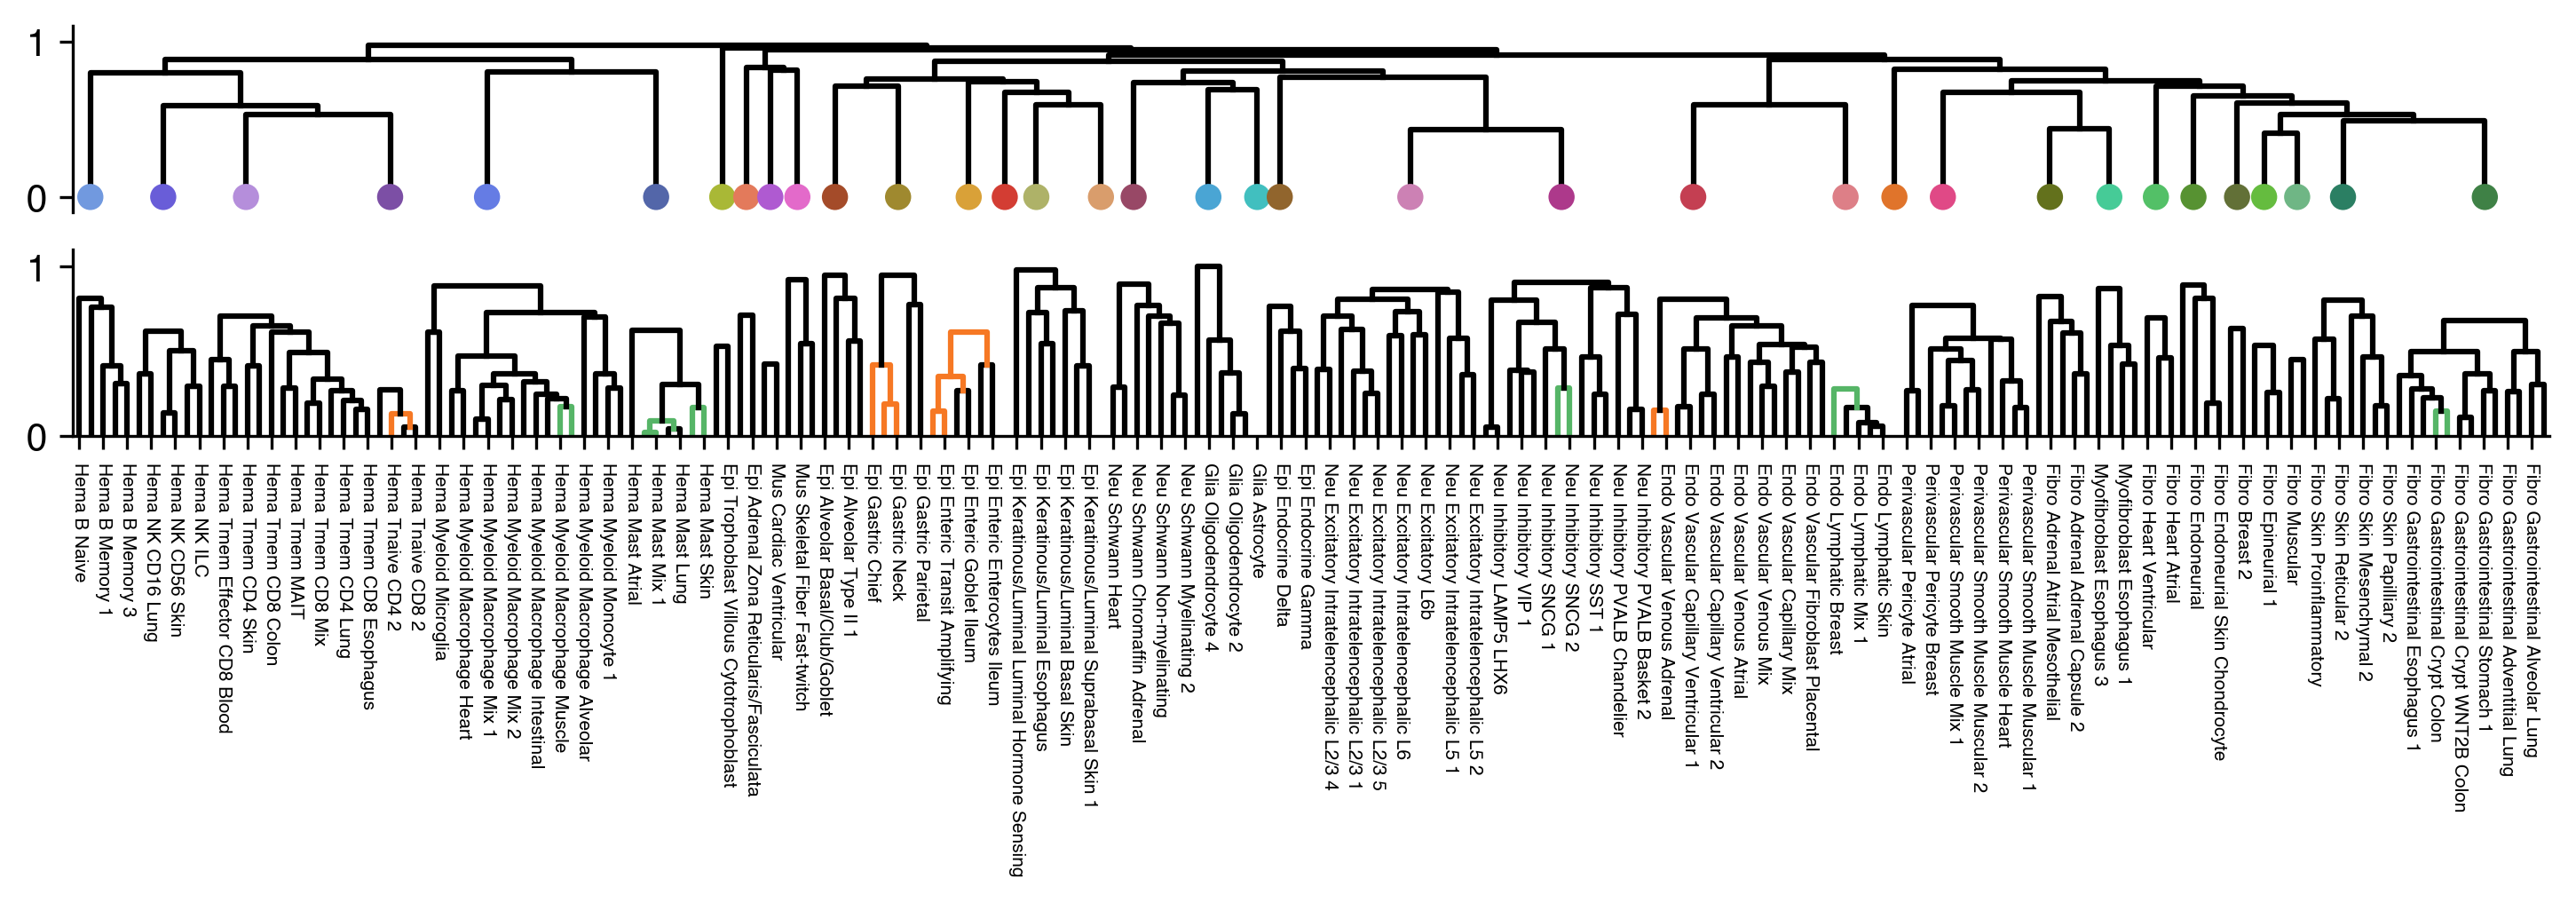

In [22]:
import os
from scipy.cluster.hierarchy import _plot_dendrogram

dendro_all = joblib.load(f'dendro_annot/All_{method_dist}_{method_hclust}.dendro')
l1order = dendro_all.dendrogram['ivl'].copy()

coord_offset = [0]
l1pos = []
xticklabels = []
# Create a figure and axis
fig, axes = plt.subplots(2, 1, figsize=(12, 2), dpi=300)

ax = axes[1]
# Iterate over the dendrogram order
for i,l1 in enumerate(l1order):
    # Load the dendrogram from file
    dendro_path = f'dendro_annot/{l1}_{method_dist}_{method_hclust}.dendro'
    if not os.path.isfile(dendro_path):
        coord_offset.append(coord_offset[-1] + 10)
        l1pos.append((coord_offset[i] + coord_offset[i+1]) / 2)
        xticklabels.append([L1_annot[l1]])
        continue
    
    dendro = joblib.load(dendro_path)
    nc = len(dendro.dendrogram['ivl'])
    coord_offset.append(coord_offset[-1] + nc * 10)

    # Modify the icoord with an offset
    modified_icoord = [[coord + coord_offset[i] for coord in coords] for coords in dendro.dendrogram['icoord']]
    dendro.dendrogram['icoord'] = modified_icoord

    # Compute score for color linkages
    # tmp = dendro.edge_stats
    tmp = dendro.linkage.copy()
    tmp['score_dis'] = 0
    selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9) & (tmp[['3C_roc', '3C_pr']].min(axis=1)<0.8)
    tmp.loc[selp] = 1
    selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)<0.8) & (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9)
    tmp.loc[selp] = -1
    # tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
    # tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)

    icoord = np.concatenate(dendro.dendrogram['icoord'])
    dcoord = np.concatenate(dendro.dendrogram['dcoord'])
    l1pos.append(np.mean(icoord[dcoord==np.max(dcoord)]))
    
    # Plot the dendrogram
    
    for xx,yy,zz in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord'], tmp['score_dis'].values):
        if zz>0:
            c = color_mc
        elif zz<0:
            c = color_3c
        else:
            c = 'k'
        ax.plot(xx, yy, color=c)

    xticklabels.append(dendro.dendrogram['ivl'])
    # _plot_dendrogram(dendro.dendrogram['icoord'], 
    #                  dendro.dendrogram['dcoord'], 
    #                  dendro.dendrogram['ivl'], 
    #                  p=30, 
    #                  n=dendro.linkage.shape[0]+1, 
    #                  mh=dendro.linkage.values[:, :2].max(), 
    #                  orientation='top', 
    #                  no_labels=False, 
    #                  color_list=dendro.dendrogram['color_list'],
    #                  leaf_font_size=8,
    #                  leaf_rotation=90,
    #                  # contraction_marks=contraction_marks,
    #                  ax=ax,
    #                  # above_threshold_color=above_threshold_color
    #                 )

ax.set_ylim([0, 1.1])
xticklabels = np.concatenate(xticklabels)
selticks = (np.arange(len(xticklabels))%2)==0
ax.set_xticks(np.arange(len(xticklabels))[selticks]*10+5)
ax.set_xticklabels(xticklabels[selticks], rotation=270, fontsize=5)
ax.set_xlim([0, len(xticklabels)*10])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

ax = axes[0]

# Modify the icoord with an offset
node_pos = {xx:[l1pos[i], 0] for i,xx in enumerate(dendro_all.dendrogram['leaves'])}
icoord, dcoord = [], []
for xx,yy,zz in dendro_all.linkage.values[:, :3]:
    pos1, pos2 = node_pos[xx], node_pos[yy]
    icoord.append([pos1[0], pos1[0], pos2[0], pos2[0]])
    dcoord.append([pos1[1], zz, zz, pos2[1]])
    node_pos[len(node_pos)] = [np.mean([pos1[0], pos2[0]]), zz]
    
# modified_icoord = [[coord + coord_offset[i] for coord in coords] for coords in dendro.dendrogram['icoord']]
# dendro.dendrogram['icoord'] = modified_icoord

# Compute score for color linkages
tmp = dendro_all.linkage.copy()
tmp['score_dis'] = 0
selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9) & (tmp[['3C_roc', '3C_pr']].min(axis=1)<0.8)
tmp.loc[selp] = 1
selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)<0.8) & (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9)
tmp.loc[selp] = -1
# tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
# tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)

for xx,yy,zz in zip(icoord, dcoord, tmp['score_dis'].values):
    if zz>0:
        c = color_mc
    elif zz<0:
        c = color_3c
    else:
        c = 'k'
    ax.plot(xx, yy, color=c)

ax.scatter(l1pos, np.zeros(len(l1pos)), s=50, c=L1_meta.loc[l1order, 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_xticks([])
ax.set_xlim([0, len(xticklabels)*10])
ax.set_ylim([-0.1, 1.1])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
                
# fig.tight_layout()
fig.savefig(f'dendro_annot/dendrogram_{method_dist}_{method_hclust}_horizontal_even.pdf', transparent=True)


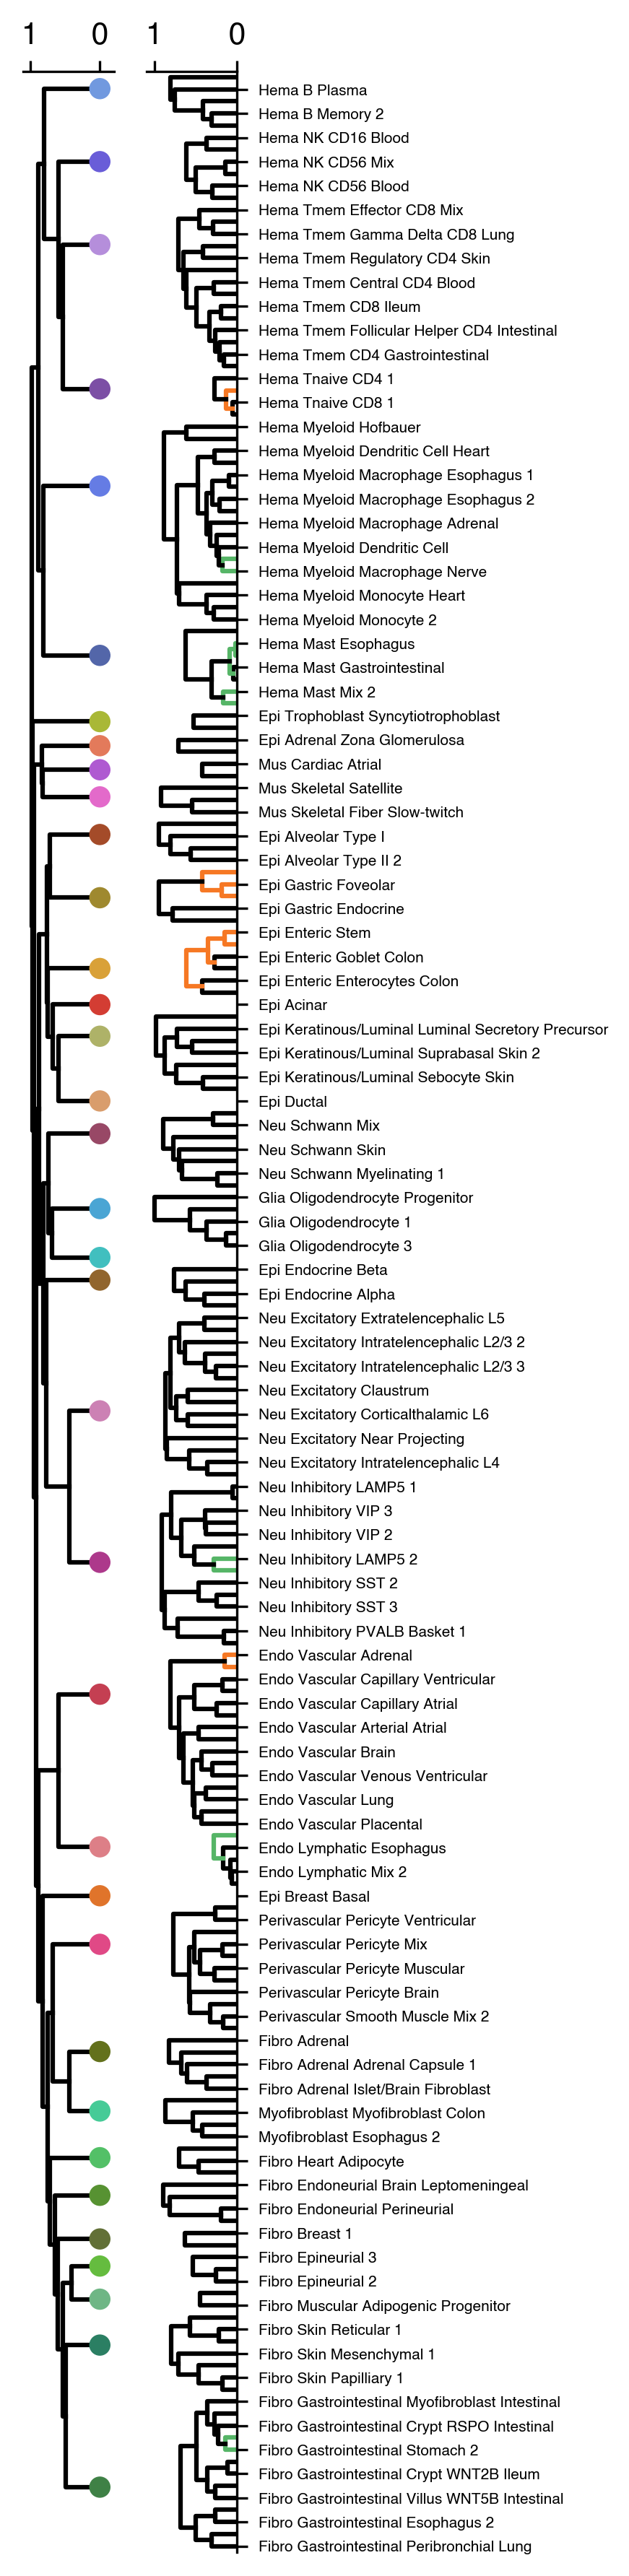

In [23]:
import os
from scipy.cluster.hierarchy import _plot_dendrogram

dendro_all = joblib.load(f'dendro_annot/All_{method_dist}_{method_hclust}.dendro')
l1order = dendro_all.dendrogram['ivl'].copy()

coord_offset = [0]
l1pos = []
xticklabels = []
# Create a figure and axis
fig, axes = plt.subplots(1, 2, figsize=(3, 12), dpi=300)

ax = axes[1]
# Iterate over the dendrogram order
for i,l1 in enumerate(l1order):
    # Load the dendrogram from file
    dendro_path = f'dendro_annot/{l1}_{method_dist}_{method_hclust}.dendro'
    if not os.path.isfile(dendro_path):
        coord_offset.append(coord_offset[-1] + 10)
        l1pos.append((coord_offset[i] + coord_offset[i+1]) / 2)
        xticklabels.append([L1_annot[l1]])
        continue
    
    dendro = joblib.load(dendro_path)
    nc = len(dendro.dendrogram['ivl'])
    coord_offset.append(coord_offset[-1] + nc * 10)

    # Modify the icoord with an offset
    modified_icoord = [[coord + coord_offset[i] for coord in coords] for coords in dendro.dendrogram['icoord']]
    dendro.dendrogram['icoord'] = modified_icoord

    # Compute score for color linkages
    # tmp = dendro.edge_stats
    tmp = dendro.linkage.copy()
    tmp['score_dis'] = 0
    selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9) & (tmp[['3C_roc', '3C_pr']].min(axis=1)<0.8)
    tmp.loc[selp] = 1
    selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)<0.8) & (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9)
    tmp.loc[selp] = -1
    # tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
    # tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)

    icoord = np.concatenate(dendro.dendrogram['icoord'])
    dcoord = np.concatenate(dendro.dendrogram['dcoord'])
    l1pos.append(np.mean(icoord[dcoord==np.max(dcoord)]))
    
    # Plot the dendrogram
    
    for xx,yy,zz in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord'], tmp['score_dis'].values):
        if zz>0:
            c = color_mc
        elif zz<0:
            c = color_3c
        else:
            c = 'k'
        ax.plot(yy, xx, color=c)

    xticklabels.append(dendro.dendrogram['ivl'])
    # _plot_dendrogram(dendro.dendrogram['icoord'], 
    #                  dendro.dendrogram['dcoord'], 
    #                  dendro.dendrogram['ivl'], 
    #                  p=30, 
    #                  n=dendro.linkage.shape[0]+1, 
    #                  mh=dendro.linkage.values[:, :2].max(), 
    #                  orientation='top', 
    #                  no_labels=False, 
    #                  color_list=dendro.dendrogram['color_list'],
    #                  leaf_font_size=8,
    #                  leaf_rotation=90,
    #                  # contraction_marks=contraction_marks,
    #                  ax=ax,
    #                  # above_threshold_color=above_threshold_color
    #                 )

ax.set_xlim([1.1, 0])
xticklabels = np.concatenate(xticklabels)
selticks = (np.arange(len(xticklabels))%2)==1
ax.set_yticks(np.arange(len(xticklabels))[selticks]*10+5)
ax.set_yticklabels(xticklabels[selticks], fontsize=5)
ax.set_ylim([len(xticklabels)*10, 0])
sns.despine(ax=ax, top=False, right=False, left=True, bottom=True)

ax = axes[0]

# Modify the icoord with an offset
node_pos = {xx:[l1pos[i], 0] for i,xx in enumerate(dendro_all.dendrogram['leaves'])}
icoord, dcoord = [], []
for xx,yy,zz in dendro_all.linkage.values[:, :3]:
    pos1, pos2 = node_pos[xx], node_pos[yy]
    icoord.append([pos1[0], pos1[0], pos2[0], pos2[0]])
    dcoord.append([pos1[1], zz, zz, pos2[1]])
    node_pos[len(node_pos)] = [np.mean([pos1[0], pos2[0]]), zz]
    
# modified_icoord = [[coord + coord_offset[i] for coord in coords] for coords in dendro.dendrogram['icoord']]
# dendro.dendrogram['icoord'] = modified_icoord

# Compute score for color linkages
tmp = dendro_all.linkage.copy()
tmp['score_dis'] = 0
selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9) & (tmp[['3C_roc', '3C_pr']].min(axis=1)<0.8)
tmp.loc[selp] = 1
selp = (tmp[['CG_roc', 'CG_pr']].min(axis=1)<0.8) & (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9)
tmp.loc[selp] = -1
# tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
# tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)

for xx,yy,zz in zip(icoord, dcoord, tmp['score_dis'].values):
    if zz>0:
        c = color_mc
    elif zz<0:
        c = color_3c
    else:
        c = 'k'
    ax.plot(yy, xx, color=c)

ax.scatter(np.zeros(len(l1pos)), l1pos, s=50, c=L1_meta.loc[l1order, 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_yticks([])
ax.set_ylim([len(xticklabels)*10, 0])
ax.set_xlim([1.1, -0.2])
sns.despine(ax=ax, top=False, right=True, left=True, bottom=True)

fig.tight_layout()
fig.savefig(f'dendro_annot/dendrogram_{method_dist}_{method_hclust}_vertical_odd.pdf', transparent=True)


In [24]:
pc_center.index[np.array(dendro.dendrogram['leaves'])]

Index(['c12', 'c14', 'c17', 'c18', 'c1', 'c16', 'c15', 'c10', 'c0', 'c2',
       'c13', 'c19', 'c11'],
      dtype='object', name='L1')

In [25]:
dendro.dendrogram['leaves']

[4, 6, 9, 10, 1, 8, 7, 2, 0, 12, 5, 11, 3]

In [26]:
dendro.dendrogram['ivl']

['Fibro Gastrointestinal Myofibroblast Intestinal',
 'Fibro Gastrointestinal Esophagus 1',
 'Fibro Gastrointestinal Crypt RSPO Intestinal',
 'Fibro Gastrointestinal Crypt Colon',
 'Fibro Gastrointestinal Stomach 2',
 'Fibro Gastrointestinal Crypt WNT2B Colon',
 'Fibro Gastrointestinal Crypt WNT2B Ileum',
 'Fibro Gastrointestinal Stomach 1',
 'Fibro Gastrointestinal Villus WNT5B Intestinal',
 'Fibro Gastrointestinal Adventitial Lung',
 'Fibro Gastrointestinal Esophagus 2',
 'Fibro Gastrointestinal Alveolar Lung',
 'Fibro Gastrointestinal Peribronchial Lung']

In [27]:
dendro.linkage

,0,1,2,3,CG_roc,CG_pr,3C_roc,3C_pr
13,8,7,0.113088,2,1.000000,1.000000,0.711017,0.724613
14,10,1,0.147294,2,0.998502,0.999478,0.938134,0.974338
15,9,14,0.228103,3,0.999576,0.999656,0.884227,0.913788
16,12,5,0.264138,2,0.999421,0.999944,0.971698,0.996978
17,2,0,0.268770,2,1.000000,1.000000,0.958849,0.982675
18,6,15,0.277078,4,0.999889,0.999950,0.982718,0.992174
19,11,3,0.305910,2,0.994771,0.998874,0.971024,0.993151
20,4,18,0.359297,5,0.998924,0.999929,0.975268,0.998344
21,13,17,0.365925,4,0.999479,0.999657,0.922991,0.950932
22,20,21,0.496783,9,0.998080,0.998670,0.995021,0.996996


In [28]:
# for ct in L1_list:
#     dendro = joblib.load(f'dendro_annot/{ct}.dendro')
#     tmp = dendro.edge_stats
#     tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
#     tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)
#     fig, ax = plt.subplots(figsize=(3, 1), dpi=300)
#     _ = plot_dendrogram(dendro=dendro.dendrogram,
#                         linkage_df=dendro.linkage,
#                         ax=ax,
#                         line_palette="twilight",
#                         plot_non_singleton=False,
#                         line_hue=tmp['score_con'].sort_index(),
#                         line_hue_norm=[-0.5,0.5],
#                        )
#     ax.set_title(ct, fontsize=12)
#     ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    
    

In [29]:
# for ct in L1_list:
#     dendro = joblib.load(f'dendro_annot/{ct}.dendro')
#     tmp = dendro.edge_stats
#     tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
#     # tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)
#     fig, ax = plt.subplots(figsize=(3, 1), dpi=300)
#     _ = plot_dendrogram(dendro=dendro.dendrogram,
#                         linkage_df=dendro.linkage,
#                         ax=ax,
#                         line_palette="twilight",
#                         plot_non_singleton=False,
#                         line_hue=tmp['score_dis'].sort_index(),
#                         line_hue_norm=[-1.5,1.5],
#                        )
#     ax.set_title(ct, fontsize=12)
#     ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    
    

In [30]:
# for ct in L1_list:
#     dendro = joblib.load(f'dendro_annot/{ct}_{method_dist}_{method_hclust}.dendro')
#     tmp = dendro.edge_stats
#     tmp['score_dis'] = (tmp[['CG_roc', 'CG_pr']].min(axis=1)>0.9).astype(int) - (tmp[['3C_roc', '3C_pr']].min(axis=1)>0.9).astype(int)
#     # tmp['score_con'] = tmp[['CG_roc', 'CG_pr']].min(axis=1) - tmp[['3C_roc', '3C_pr']].min(axis=1)
#     fig, ax = plt.subplots(figsize=(3, 1), dpi=300)
#     _ = plot_dendrogram(dendro=dendro.dendrogram,
#                         linkage_df=dendro.linkage,
#                         ax=ax,
#                         line_palette="twilight",
#                         plot_non_singleton=False,
#                         line_hue=tmp['score_dis'].sort_index(),
#                         line_hue_norm=[-1.5,1.5],
#                        )
#     ax.set_title(ct, fontsize=12)
#     ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    
    